This helper notebook will assist with loading the wine data into pyton

In [18]:
import os
import numpy as np

In [19]:
#paths to the data
data_directory= "/Users/ssscal/Downloads/amath482_P3" #put the directory of your data here
train_path=os.path.join(data_directory,'wine_training.csv')
test_path=os.path.join(data_directory,'wine_test.csv')

In [20]:
#loading the data
d_train = np.loadtxt(train_path, dtype=float, delimiter=',')
d_test = np.loadtxt(test_path, dtype=float, delimiter=',')

X_train = d_train[:, 0:11]
X_test = d_test[:, 0:11]

Y_train = d_train[:,11]
Y_test = d_test[:,11]

print("Training inputs shape: "+str(X_train.shape))
print("Training outputs shape: "+str(Y_train.shape))
print("Test inputs shape: "+str(X_test.shape))
print("Test outputs shape: "+str(Y_test.shape))


Training inputs shape: (1115, 11)
Training outputs shape: (1115,)
Test inputs shape: (479, 11)
Test outputs shape: (479,)


## HW3 Full Solution Workflow
This section completes Parts 1-8 from the PDF instructions using the provided `wine_training.csv` and `wine_test.csv` files.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.metrics import mean_squared_error


In [22]:
# Reload data (kept explicit so this section can run independently)
d_train = np.loadtxt(train_path, dtype=float, delimiter=',')
d_test = np.loadtxt(test_path, dtype=float, delimiter=',')

X_train = d_train[:, 0:11]
X_test = d_test[:, 0:11]

y_train = d_train[:, 11]
y_test = d_test[:, 11]

print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('y_train:', y_train.shape, 'y_test:', y_test.shape)


X_train: (1115, 11) X_test: (479, 11)
y_train: (1115,) y_test: (479,)


### Part 1: Standardization Rule
Normalize/center **using training-set statistics only**.
- Fit scaler(s) on training data.
- Apply the same transform to test data.
- Do **not** fit any scaler on test data.


In [23]:
# Standardize inputs and outputs with training statistics only
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))

X_train_s = x_scaler.transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.transform(y_train.reshape(-1, 1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print('Scaled X_train mean (first 3 cols):', np.round(X_train_s.mean(axis=0)[:3], 6))
print('Scaled y_train mean/std:', np.round(y_train_s.mean(), 6), np.round(y_train_s.std(), 6))


Scaled X_train mean (first 3 cols): [ 0. -0. -0.]
Scaled y_train mean/std: -0.0 1.0


### Part 2 & 3: First-order OLS and Top-5 Coefficients


In [24]:
ols_first = LinearRegression().fit(X_train_s, y_train_s)
y_pred_first = ols_first.predict(X_test_s)

mse_first = mean_squared_error(y_test_s, y_pred_first)
top5_idx = np.argsort(np.abs(ols_first.coef_))[-5:][::-1]

print('Part 2 test MSE (first-order OLS):', mse_first)
print('Part 3 top-5 coefficient indices:', top5_idx.tolist())


Part 2 test MSE (first-order OLS): 0.7471696905187212
Part 3 top-5 coefficient indices: [10, 1, 9, 6, 4]


### Part 4 & 5: Second-order (Quadratic, No Interactions) OLS


In [25]:
X_train_quad = np.hstack([X_train_s, X_train_s**2])
X_test_quad = np.hstack([X_test_s, X_test_s**2])

ols_quad = LinearRegression().fit(X_train_quad, y_train_s)
y_pred_quad = ols_quad.predict(X_test_quad)

mse_quad = mean_squared_error(y_test_s, y_pred_quad)
print('Part 4 test MSE (quadratic OLS):', mse_quad)
print('Part 5 conclusion: quadratic terms improve?' , 'Yes' if mse_quad < mse_first else 'No')


Part 4 test MSE (quadratic OLS): 0.7805821192127664
Part 5 conclusion: quadratic terms improve? No


### Part 6: Interaction Model (Specified Indices)
Use `index=[1,4,6,9,10]` and include:
- all first-order terms
- all pairwise interactions among those indices


In [26]:
index = [1, 4, 6, 9, 10]
pairs = list(combinations(index, 2))

X_train_int = X_train_s.copy()
X_test_int = X_test_s.copy()

for i, j in pairs:
    X_train_int = np.column_stack([X_train_int, X_train_s[:, i] * X_train_s[:, j]])
    X_test_int = np.column_stack([X_test_int, X_test_s[:, i] * X_test_s[:, j]])

ols_int = LinearRegression().fit(X_train_int, y_train_s)
y_pred_int = ols_int.predict(X_test_int)
mse_int = mean_squared_error(y_test_s, y_pred_int)

print('Part 6 test MSE (interaction OLS):', mse_int)
print('Interaction pairs:', pairs)


Part 6 test MSE (interaction OLS): 0.7175224728219507
Interaction pairs: [(1, 4), (1, 6), (1, 9), (1, 10), (4, 6), (4, 9), (4, 10), (6, 9), (6, 10), (9, 10)]


### Part 7: Lasso Model Selection on Interaction Model


In [27]:
alphas = np.logspace(-4, 2, 300)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=200000, random_state=0).fit(X_train_int, y_train_s)
selected_alpha = lasso_cv.alpha_

lasso_refit = Lasso(alpha=selected_alpha, max_iter=200000).fit(X_train_int, y_train_s)
y_pred_lasso = lasso_refit.predict(X_test_int)
mse_lasso = mean_squared_error(y_test_s, y_pred_lasso)

feature_names = [f'x{i}' for i in range(11)] + [f'x{i}*x{j}' for i, j in pairs]
nonzero = [(name, coef) for name, coef in zip(feature_names, lasso_refit.coef_) if abs(coef) > 1e-10]

print('Part 7 selected alpha:', selected_alpha)
print('Part 7 test MSE (interaction Lasso):', mse_lasso)
print('Part 7 nonzero coefficients:')
for name, coef in nonzero:
    print(f'  {name}: {coef:.12f}')


Part 7 selected alpha: 0.00969665789314552
Part 7 test MSE (interaction Lasso): 0.704284839101328
Part 7 nonzero coefficients:
  x1: -0.255268781954
  x2: -0.069358702094
  x4: -0.073864822203
  x5: 0.060657925889
  x6: -0.175509312713
  x8: -0.068216393057
  x9: 0.273823576746
  x10: 0.324182831075
  x1*x6: 0.087547395608
  x1*x9: 0.004148092803
  x4*x9: -0.024167205652
  x4*x10: -0.004476338662
  x6*x9: -0.075640612572
  x9*x10: 0.036527294187


### Figure 1: LassoCV Selection Curve (Task 7)
Plot mean CV MSE vs `alpha` (log-scale), with a vertical line at the selected `alpha`.


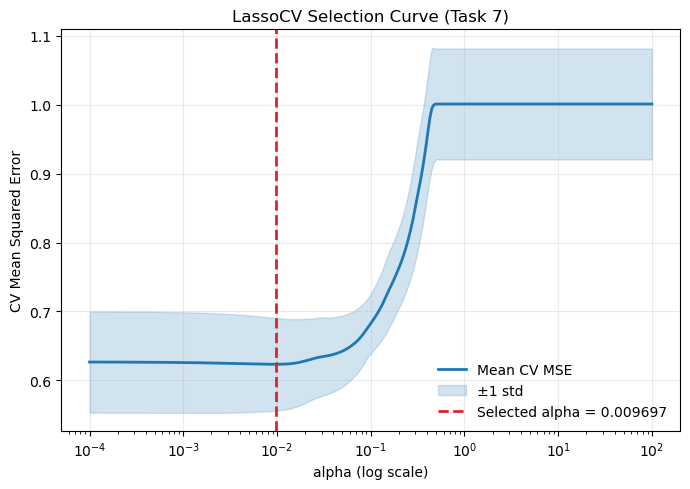

Saved: fig_lassocv_selection_curve.png


In [28]:
cv_mean = lasso_cv.mse_path_.mean(axis=1)
cv_std = lasso_cv.mse_path_.std(axis=1)
alphas_cv = lasso_cv.alphas_

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(alphas_cv, cv_mean, linewidth=2, color='#1f77b4', label='Mean CV MSE')
ax.fill_between(alphas_cv, cv_mean - cv_std, cv_mean + cv_std, color='#1f77b4', alpha=0.2, label='±1 std')
ax.axvline(selected_alpha, color='#d62728', linestyle='--', linewidth=2, label=f'Selected alpha = {selected_alpha:.4g}')
ax.set_title('LassoCV Selection Curve (Task 7)')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('CV Mean Squared Error')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig('fig_lassocv_selection_curve.png', dpi=200)
plt.show()
print('Saved: fig_lassocv_selection_curve.png')


### Part 8: Best Model + Final Conclusions


In [29]:
model_mse = {
    'first_order_ols': mse_first,
    'quadratic_ols': mse_quad,
    'interaction_ols': mse_int,
    'interaction_lasso': mse_lasso,
}
best_model = min(model_mse, key=model_mse.get)

print('Model comparison (lower is better):')
for k, v in model_mse.items():
    print(f'  {k}: {v:.12f}')

print(f'\nBest model: {best_model} ({model_mse[best_model]:.12f})')
print('Interaction terms helpful?', 'Yes' if model_mse['interaction_ols'] < model_mse['first_order_ols'] else 'No')
print('Best overall from tested models uses interactions?', 'Yes' if 'interaction' in best_model else 'No')


Model comparison (lower is better):
  first_order_ols: 0.747169690519
  quadratic_ols: 0.780582119213
  interaction_ols: 0.717522472822
  interaction_lasso: 0.704284839101

Best model: interaction_lasso (0.704284839101)
Interaction terms helpful? Yes
Best overall from tested models uses interactions? Yes


### Figure 2: `y_true` vs `y_pred` Scatter (Best Model: `interaction_lasso`)
Use original quality scale to visualize calibration and residual spread.


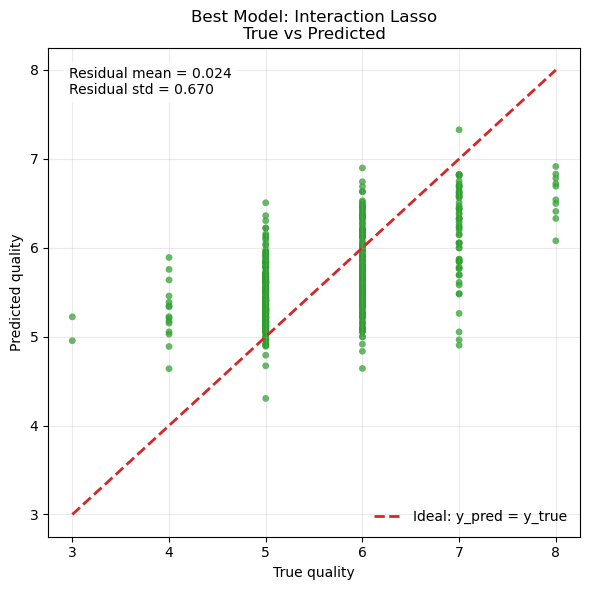

Saved: fig_interaction_lasso_true_vs_pred.png


In [30]:
# Convert predictions back to original quality scale
y_pred_lasso_orig = y_scaler.inverse_transform(y_pred_lasso.reshape(-1, 1)).ravel()
residuals = y_pred_lasso_orig - y_test

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lasso_orig, s=24, alpha=0.75, color='#2ca02c', edgecolor='none')
lo = min(y_test.min(), y_pred_lasso_orig.min())
hi = max(y_test.max(), y_pred_lasso_orig.max())
ax.plot([lo, hi], [lo, hi], '--', color='#d62728', linewidth=2, label='Ideal: y_pred = y_true')
ax.set_title('Best Model: Interaction Lasso\nTrue vs Predicted')
ax.set_xlabel('True quality')
ax.set_ylabel('Predicted quality')
ax.text(0.04, 0.96, f'Residual mean = {residuals.mean():.3f}\nResidual std = {residuals.std():.3f}', transform=ax.transAxes, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig('fig_interaction_lasso_true_vs_pred.png', dpi=200)
plt.show()
print('Saved: fig_interaction_lasso_true_vs_pred.png')


## Report-ready Answer Snapshot 
- Part 1: Test set must be transformed with **training** mean/std only.
- Part 2: First-order OLS test MSE = **0.747169690519**.
- Part 3: Largest-|coef| predictor indices = **[10, 1, 9, 6, 4]**.
- Part 4: Quadratic (no interactions) OLS test MSE = **0.780582119213**.
- Part 5: Quadratic terms did **not** improve performance vs first-order OLS.
- Part 6: Interaction OLS test MSE = **0.717522472822**.
- Part 7: LassoCV selected alpha = **0.00969665789315**, test MSE = **0.704284839101**.
- Part 8: Best test MSE is from **interaction_lasso**; including interaction terms is beneficial here.
